# Exercises for Section 3.3 Introduction to hypothesis testing

This notebook contains the solutions to the exercises
from [Section 3.3 Introduction to hypothesis testing]()
in the **No Bullshit Guide to Statistics**.

### Notebooks setup

In [1]:
# Ensure required Python modules are installed
%pip install --quiet numpy scipy seaborn pandas ministats

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Figures setup
plt.clf()  # needed otherwise `sns.set_theme` doesn't work
sns.set_theme(
    context="paper",
    style="whitegrid",
    palette="colorblind",
    rc={"figure.figsize": (5, 1.6)},
)
%config InlineBackend.figure_format = "retina"

<Figure size 640x480 with 0 Axes>

In [4]:
# Simplified int and float __repr__
np.set_printoptions(legacy='1.25')

In [5]:
# Download datasets/ directory if necessary
from ministats import ensure_datasets
ensure_datasets()

datasets/ directory already exists.


$\def\stderr#1{\mathbf{se}_{#1}}$
$\def\stderrhat#1{\hat{\mathbf{se}}_{#1}}$
$\newcommand{\Mean}{\textbf{Mean}}$
$\newcommand{\Var}{\textbf{Var}}$
$\newcommand{\Std}{\textbf{Std}}$
$\newcommand{\Freq}{\textbf{Freq}}$
$\newcommand{\RelFreq}{\textbf{RelFreq}}$
$\newcommand{\DMeans}{\textbf{DMeans}}$
$\newcommand{\Prop}{\textbf{Prop}}$
$\newcommand{\DProps}{\textbf{DProps}}$
$$
\newcommand{\CI}[1]{\textbf{CI}_{#1}}
\newcommand{\CIL}[1]{\textbf{L}_{#1}}
\newcommand{\CIU}[1]{\textbf{U}_{#1}}
\newcommand{\ci}[1]{\textbf{ci}_{#1}}
\newcommand{\cil}[1]{\textbf{l}_{#1}}
\newcommand{\ciu}[1]{\textbf{u}_{#1}}
$$
(this cell contains the macro definitions like $\stderr{\overline{\mathbf{x}}}$, $\stderrhat{}$, $\Mean$, ...)

## Exercises

### E3.23
<!-- {exercise:simulation-test-mean-batch-05} -->

Run the hypothesis test for the mean
of the volume measurements from Batch 05 of the kombucha dataset.

**a)** Formulate two competing hypotheses $H_0$ and $H_A$.

**b)** Calculate the sample mean $\overline{\mathbf{k}}_{05}$.

**c)** Simulate $10\,000$ observations
from the sampling distribution of the mean $\overline{\mathbf{K}}_0$
under the null model $K_0 \sim \mathcal{N}(\mu_{K_0}\!=\!1000, \sigma_{K_0}\!=\!10)$.

**d)** Compute the two-sided $p$-value
of the observed $\overline{\mathbf{k}}_{05}$
under $\overline{\mathbf{K}}_0$.

**e)** Make a decision about Batch 05 using the cutoff value $\alpha\!=\!0.05$.

Hint: Use `gen_sampling_dist` to obtain the sampling distribution.

In [6]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample05 = kombucha[kombucha["batch"]==5]["volume"]
len(ksample05)

40

In [7]:
ksample05.head()

107     998.35
108     998.92
109    1005.38
110    1007.20
111    1010.62
Name: volume, dtype: float64

**a)** 
The two competing hypotheses are:
$$ 
  H_0: \mu = \mu_{K_0}
  \qquad\text{and}\qquad
  H_A: \mu \neq \mu_{K_0},
$$
where $\mu_{K_0}=1000$ is the expected mean when the production line is working as expected.

In [9]:
# b) Compute the observed mean
obsmean05 = np.mean(ksample05)
obsmean05

1002.53475

In [11]:
# Population data model under H0
from scipy.stats import norm
rvK0 = norm(1000, 10)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(42)

# b) Generate the sampling distribution under H0
from ministats import gen_sampling_dist
kbars40 = gen_sampling_dist(rvK0, estfunc=np.mean, n=40)

In [13]:
# c) Compute the p-value of `obsmean05` under H0
obsdev05 = abs(obsmean05 - 1000)
tails = [v for v in kbars40 if abs(v-1000) >= obsdev05]
pvalue05 = len(tails) / len(kbars40)
pvalue05

0.1089

The $p$-value is greater than $\alpha = 0.05$ so we have failed to reject $H_0$.
Batch 05 is OK.

Let's plot the sampling distribution $\overline{\mathbf{K}}_0$
under $H_0$ and the observed sample mean $\overline{\mathbf{k}}_{05}$.

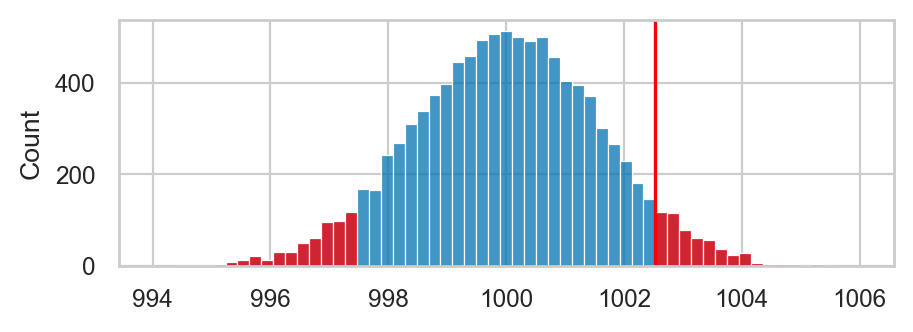

In [14]:
# Choose bins for the histogram aligned with `obsmean05`
from ministats import nicebins
bins = nicebins(kbars40, obsmean05)

# Plot showing `obsmean05` fits within the sampling distribution under H0
sns.histplot(kbars40, bins=bins)
plt.axvline(obsmean05 , color="red")
sns.histplot(tails, bins=bins, color="red");

The function `simulation_test_mean` from the `ministats` library
performs all the steps of the simulation test for the mean.
We can use this function to check we got the above calculations right.

In [15]:
# Set the random seed to the same value as above to reproduce result
np.random.seed(42)

# Check answer using `ministats` helper function
from ministats import simulation_test_mean
simulation_test_mean(ksample05, mu0=1000, sigma0=10)

0.1091

### E3.24

<!-- {exercise:simulation-test-mean-batch-06} -->

Run a hypothesis test for the mean $\mu$ of kombucha Batch 06.
Compute a $p$-value and make a decision based on the cutoff $\alpha\!=\!0.05$.
Compute a point estimate $\hat{\Delta}$
for the effect size $\Delta = \mu_{06} - \mu_{K_0}$
and a $90\%$ confidence interval for the effect size $\ci{\Delta,0.9}$.

Hint: You can use the helper function `ci_mean` with the option `method="b"`
to construct a bootstrap confidence interval for $\mu_{06}$.


In [16]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample06 = kombucha[kombucha["batch"]==6]["volume"]
len(ksample06)

40

In [18]:
# Compute the observed mean
obsmean06 = np.mean(ksample06)
obsmean06

995.9955

In [20]:
# Population data model under H0
from scipy.stats import norm
rvK0 = norm(1000, 10)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(43)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
kbars40 = gen_sampling_dist(rvK0, estfunc=np.mean, n=40)

# Compute the p-value of `obsmean06` under H0
obsdev06 = abs(obsmean06 - 1000)
tails = [v for v in kbars40 if abs(v-1000) >= obsdev06]
pvalue06 = len(tails) / len(kbars40)
pvalue06

0.0118

The $p$-value is less than $\alpha = 0.05$ so we reject $H_0$.
Batch 06 is irregular.

Let's plot the sampling distribution $\overline{\mathbf{K}}_0$
under $H_0$ and the observed sample mean $\overline{\mathbf{k}}_{06}$.

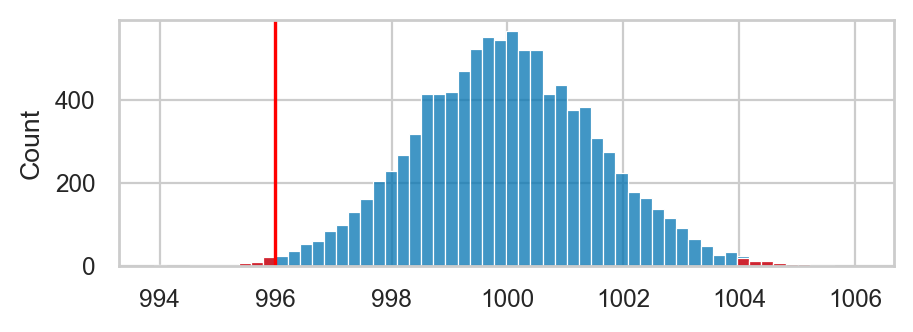

In [21]:
# Choose bins for the histogram aligned with `obsmean06`
from ministats import nicebins
bins = nicebins(kbars40, obsmean06)

# Plot showing `obsmean06` fits within the sampling distribution under H0
sns.histplot(kbars40, bins=bins)
plt.axvline(obsmean06 , color="red")
sns.histplot(tails, bins=bins, color="red");

The function `simulation_test_mean` from the `ministats` library
performs all the steps of the simulation test for the mean.
We can use this function to check we got the above calculations right.

In [22]:
# ALT. Use the pre-defined function `simulation_test_mean`
# Set the random seed to the same value as above to reproduce result
np.random.seed(43)

# Check answer using `ministats` helper function
from ministats import simulation_test_mean
simulation_test_mean(ksample06, mu0=1000, sigma0=10)

0.0125

In [24]:
# Point estimate for the effect size
obsmean06 - 1000

-4.004500000000007

In [26]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(42)

# Construct a 90% confidence interval for the effect size
from ministats import ci_mean
cimu06 = ci_mean(ksample06, alpha=0.1, method="b")
ciDelta06 = [cimu06[0]-1000, cimu06[1]-1000]
ciDelta06

[-6.765137500000037, -1.335712500000227]

The 90% confidence interval for the effect size is $\ci{\Delta,0.9} = [-6.8, -1.3]$.

### E3.25

<!-- {exercise:simulation-test-var-batch-01} -->

Run a hypothesis test for the variance of Batch 01
using the hypotheses $H_A:\sigma^2>\sigma_{K_0}^2$
and $H_0:\sigma^2\leq\sigma_{K_0}^2$,
where $\sigma_{K_0}^2=100$.
Compute the right-tailed $p$-value and make a decision
based on the cutoff value $\alpha=0.05$ whether to ship Batch 01 or not.

In [27]:
kombucha = pd.read_csv("datasets/kombucha.csv")
ksample01 = kombucha[kombucha["batch"]==1]["volume"]
len(ksample01)

40

In [28]:
ksample01.head()

0    1016.24
1     993.88
2     994.72
3     989.27
4    1008.65
Name: volume, dtype: float64

In [29]:
# Define the variance estimator function
def var(sample):
    xbar = sum(sample) / len(sample)
    sumsqdevs = sum([(xi-xbar)**2 for xi in sample])
    return sumsqdevs / (len(sample)-1)

In [31]:
# Compute the observed variance
obsvar01 = var(ksample01)
obsvar01

95.4365419871796

In [33]:
# Population data model under H0
from scipy.stats import norm
rvK0 = norm(1000, 10)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(44)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
kvars40 = gen_sampling_dist(rvK0, estfunc=var, n=40)

# Compute the p-value of `obsvar01` under H0
tail = [v for v in kvars40 if v >= obsvar01]
pvalue01 = len(tail) / len(kvars40)
pvalue01

0.5451

The $p$-value is greater than $\alpha=0.05$
so we fail to reject $H_0$.

Let's plot the sampling distribution $S_{\mathbf{K}_0}^2$
under $H_0$ and the observed sample mean $s_{\mathbf{k}_{05}}^2$.

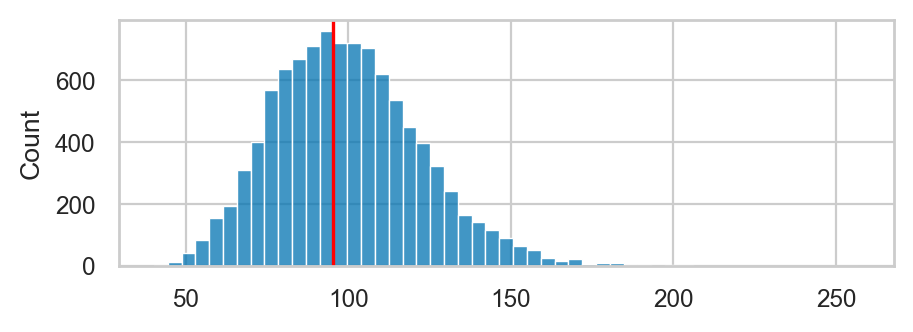

In [34]:
# Choose bins for the histogram aligned with `obsvar01`
from ministats import nicebins
bins = nicebins(kvars40, obsvar01)

# Show where `obsvar01` fits within the sampling distribution under H0
sns.histplot(kvars40, bins=bins)
plt.axvline(obsvar01 , color="red")
sns.histplot(tails, bins=bins, color="red");

The function `simulation_test_var` from the `ministats` library
performs all the steps of the simulation test for the variance.
We can use this function to check we got the above calculations right.

In [35]:
# Set the random seed to a particular value to get a reproducible result
np.random.seed(44)

# Check answer using `ministats` helper function
from ministats import simulation_test_var
simulation_test_var(ksample01, mu0=1000, sigma0=10)

0.5451

### E3.26 Drug discovery

<!-- {exercise:similation-test-drug-discovery} -->

Suppose the baseline model for the health indicator
for people who suffer from some ailment
is $I_0 \sim \mathcal{N}(\mu_{I_0}\!=\!100, \sigma_{I_0}\!=\!1)$.
A group of $10$ patients were treated with a new drug,
and their health indicator measurements
after the treatment are
$\mathbf{i} = (101.9, 100.4,  99.9, 100.4, 101.1, 100.8, 100.8, 101.2,  99.8, 102.5)$.
You want to know if the new drug
has an effect on the health indicator
so you run a hypothesis test
based on the hypotheses $H_A: \mu \neq \mu_{I_0}$
and $H_0: \mu = \mu_{I_0}$.
Compute the $p$-value under the baseline model $I_0$
and make a decision using the cutoff $\alpha=0.05$.

Hint: Create a computer model for the population data model
$I_0 \sim \mathcal{N}(\mu_{I_0}\!=\!100, \sigma_{I_0}\!=\!1)$
then use `gen_sampling_dist` to obtain the sampling distribution of the mean
under the null hypothesis.


In [36]:
# This is the code I used to generate the data for this exercise:
from scipy.stats import norm
Delta = 1   # true effect size
rvI = norm(100+Delta, 1)
n = 10
np.random.seed(76)
isample_raw = rvI.rvs(n)
isample = isample_raw.round(1)
print("mean =", isample.mean().round(3), "    std =", isample.std().round(3))
print(isample)

mean = 100.88     std = 0.801
[101.9 100.4  99.9 100.4 101.1 100.8 100.8 101.2  99.8 102.5]


In [37]:
# The observed data sample
isample = [101.9, 100.4,  99.9, 100.4, 101.1,
           100.8, 100.8, 101.2,  99.8, 102.5]

In [39]:
# Compute the observed variance
obsimean = np.mean(isample)
obsimean

100.88

In [41]:
# Population data model under H0
from scipy.stats import norm
rvI0 = norm(100, 1)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(46)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
ibars10 = gen_sampling_dist(rvI0, estfunc=np.mean, n=10)

# Compute the p-value of `obsimean` under H0
obsdev = abs(obsimean - 100)
tails = [v for v in ibars10 if abs(v-100) >= obsdev]
pvalue = len(tails) / len(ibars10)
pvalue

0.0058

In [42]:
np.random.seed(46)
# Check answer using `ministats` helper function
from ministats import simulation_test_mean
simulation_test_mean(isample, mu0=100, sigma0=1)

0.0059

The $p$-value is less than $\alpha = 0.05$ so we reject $H_0$.
The drug seems to have an effect on the health indicator.

### E3.27 Software engineering

<!-- {exercise:similation-test-software-eng} -->

Your company uses the baseline model
$B_0 \sim \mathrm{Pois}(\lambda_{B_0}\!=\!10)$
for the expected number of bugs per hour for your software.
The bug counts observed for the current release during the past 12 hours
are $\mathbf{b} = (15, 14,  9, 10, 11, 19, 10, 12, 12, 11,  8, 15)$.
You want to check if the current release is "extra buggy"
by running a hypothesis test
based on the hypotheses $H_A: \mu > \lambda_{B_0}$
and $H_0: \mu \leq \lambda_{B_0}$.
Compute the $p$-value for this hypothesis test on the sample $\mathbf{b}$
and make a decision based on the cutoff value $\alpha = 0.05$.

Hint: Create a computer model for the population data model $B_0 \sim \mathrm{Pois}(\lambda_{B_0} = 10)$
then use `gen_sampling_dist` to obtain the sampling distribution of the mean
under the null hypothesis.



In [43]:
bsample = [15, 14,  9, 10, 11, 19, 10, 12, 12, 11,  8, 15]

In [44]:
# This is the code I used to generate the data for this exercise:
from scipy.stats import poisson
Delta = 1   # true effect size
rvB = poisson(mu=10+Delta)
n = 12
np.random.seed(44)
bs = rvB.rvs(n)
print("mean =", bs.mean().round(3), "    std =", bs.std().round(3))
list(bs)

mean = 12.167     std = 2.967


[15, 14, 9, 10, 11, 19, 10, 12, 12, 11, 8, 15]

In [46]:
# Compute the observed mean
obsbmean = np.mean(bsample)
obsbmean

12.166666666666666

In [48]:
# Population data model under H0
from scipy.stats import poisson
rvB0 = poisson(mu=10)

# Set the random seed to a particular value to get a reproducible result
np.random.seed(47)

# Generate the sampling distribution under H0
from ministats import gen_sampling_dist
bbars12 = gen_sampling_dist(rvB0, estfunc=np.mean, n=12)

# Compute the p-value of `obsbmean` under H0
tail = [v for v in bbars12 if v >= obsbmean]
pvalue = len(tail) / len(bbars12)
pvalue

0.0116

The $p$-value is less than $\alpha = 0.05$ so we reject $H_0$.
This seems to be an unusually buggy release,
so you better look into what's wrong with it.

### E3.28

<!-- {exercise:similation-test-scientific-discovery} -->


According to Newtonian physics,
the gravitational field of the Sun should cause light passing near its surface
to be deflected by about $0.87$ arcseconds,
where an arcsecond is a unit used for measuring small angles:
$1$ degree = $3600$ arcseconds.
In 1915,
Albert Einstein proposed a revolutionary new theory about the nature of gravity.
Einstein's theory of *general relativity*
predicts that light passing near the surface of the Sun
will be deflected by $1.75$ arcseconds,
which is more than the prediction obtained by Newtonian physics.
During the total solar eclipse of 1919,
Arthur Eddington and Edwin Cottingham
got a unique opportunity to test Einstein's predictions experimentally
by taking pictures of distant stars whose light passed close to the Sun.
They measured the deflections of five stars:
$\mathbf{d} = (0.63, 1.12, 1.61, 2.10, 2.59)$.
Perform a statistical analysis
to check whether the observed measurements $\mathbf{d}$
are sufficient to reject the Newtonian null hypothesis.
Einstein's theory predicts that deflection will be greater than $0.87$ arcseconds,
which we'll write as the alternative hypothesis $H_A:\mu_D > 0.87$.
We'll compare $H_A$
to the Newtonian null hypothesis $H_0:\mu_D \leq 0.87$.
For this exercise,
you can assume that light deflection measurements are normally distributed
with standard deviation $\sigma_D=0.99$ arcseconds.

**a)** Calculate the mean deflection $\overline{\mathbf{d}}$.

**b)** Obtain the sampling distribution of the mean $\overline{\mathbf{D}}_0$
for samples of size $n=5$
from the null data model $D_0 \sim \mathcal{N}(0.87,0.99)$.

**c)** Calculate the one-sided $p$-value of the observed $\overline{\mathbf{d}}$
under $\overline{\mathbf{D}}_0$.

**d)** What conclusion can you draw from your analysis?
Use the conventional cutoff value of $\alpha=0.05$
to make your decision.


In [49]:
# Observed deflection measurements
dsample = [0.63, 1.12, 1.61, 2.10, 2.59]

In [51]:
# a) Compute the observed mean
obsdmean = np.mean(dsample)
obsdmean

1.61

In [53]:
# Population data model under H0 (Newtonian physics)
from scipy.stats import norm
rvD0 = norm(0.87, 0.99)

# Set the random seed to get a reproducible result
np.random.seed(46)

# b) Generate the sampling distribution of the mean under H0
from ministats import gen_sampling_dist
dbars5 = gen_sampling_dist(rvD0, estfunc=np.mean, n=5)

In [55]:
# c) Compute the one-sided p-value under H0
tail = [dbar for dbar in dbars5 if dbar >= obsdmean]
pvalue = len(tail) / len(dbars5)
pvalue

0.0495

We must now interpret the $p$-value $0.0495$
in the context of the research question.
We performed the probability calculations under the null
model predicted by Newtonian physics.
Assuming the Newtonian model is true,
we calculated that less than $5\%$ of samples of size $n=5$
will have a mean deflection of $\overline{\mathbf{d}}=1.61$ arcseconds or larger.
Using the conventional cutoff value of $\alpha=0.05$,
we reject the Newtonian null hypothesis.
In other words,
we're saying that the observed deflections $\mathbf{d}$
are not consistent with the Newtonian model,
so it's worth looking into Einstein's new theory.

Note that the sample $\mathbf{d} = (0.63, 1.12, 1.61, 2.10, 2.59)$
is a simplified synthetic dataset
that I chose to match the historical mean deflection $\overline{\mathbf{d}}=1.61$,
which was obtained by other means.

### E3.29

Your company produces memory chips (RAM modules).
You're in charge of reliability testing at the final packaging step of the production line.
You test $n$ chips from the current batch
and obtain an estimate $\overline{\mathbf{x}}$ of the mean error rate.
You also know the sampling distribution of the mean error rate $\overline{\mathbf{X}}_0$
when the production line is working as expected.
You want to determine whether the current batch
has a *higher* error rate than expected,
so you apply the appropriate one-sided hypothesis test for the mean
and obtain the upper-tail $p$-value of $0.01$.

**a)** Explain in your own words what this $p$-value means.

**b)** What decision would you make in this situation?
Will you ship this batch or not?

**c)** Explain why you made the decision in **b)** to your boss.

Hint: Start by choosing the cutoff value $\alpha$ for your decision.



In part **a)**,
we're asked to explain what the $p$-value is.
Based on the wording of the question,
we're comparing the hypotheses $H_A: \mu > \mu_0$
and $H_0: \mu \leq \mu_0$.
The $p$-value is the probability of observing a sample mean error rate
at least as high as $\overline{\mathbf{x}}$,
assuming the production line is working as expected.

To answer **b)**,
we must first choose an appropriate cutoff value $\alpha$,
which is an important *statistical design* decision.
How many false positives can we tolerate?
What properties do we want the test to have?
There is no standard or correct choice for $\alpha$
based on statistical principles alone.
Instead,
we design the statistical test based on the real-world
costs or "loss" of making a wrong decision.
We must trade off
lost revenue from each batch that you don't ship,
versus the reputational damage the company would suffer for shipping a defective batch.
The conventional
$\alpha=0.05$ is definitely not appropriate here:
you could falsely stop about $5$ out of $100$ good batches!
Good luck justifying that to your boss!
Let's say you choose the cutoff $\alpha=0.001$
which limits the false-positive probability to at most $0.001$,
i.e. one false positive for every $1000$ good batches.
Based on the $\alpha=0.001$ cutoff,
our decision is to fail to reject $H_0$.
We'll act as if the batch is fine and ship it!

For part **c)**,
you could explain to your boss that you picked the $\alpha=0.001$ cutoff
which is very stringent because you want the production line to keep running
most of the time,
but still want to catch extremely problematic batches with higher error rates.
Selling RAM modules is a very hot business in the generative AI era
so there is very little risk of reputational damage.
The CEOs of the client companies are all
[suffering from mass AI psychosis](https://ludic.mataroa.blog/blog/ai-mania-is-eviscerating-global-decision-making/)
so they would keep buying from your company even if you send them a bad batch or two.
In fact,
you could probably ship them dog poop in a paper bag,
and they would still keep buying chips from you!